# Sistem Rekomendasi Film Menggunakan Ekstraksi Fitur LLM dan Algoritma TF-IDF Cosine Similarity

    1. Christella Cindy Wijaya - 2802407742
    2. Deron Garcia 
    3. James Michael Lionel

In [ ]:
# Import library

import pandas as pd
import ast
import pickle
import google.generativeai as genai
import optuna
import matplotlib.pyplot as plt

from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.neighbors import NearestNeighbors
from optuna.pruners import MedianPruner

## 1. Data Merging & Cleaning

### Load Data

In [3]:
data_film = pd.read_csv('tmdb_5000_movies.csv')
data_orang = pd.read_csv('tmdb_5000_credits.csv')

print(data_film.head())
print(data_orang.head())

      budget                                             genres  \
0  237000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
1  300000000  [{"id": 12, "name": "Adventure"}, {"id": 14, "...   
2  245000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
3  250000000  [{"id": 28, "name": "Action"}, {"id": 80, "nam...   
4  260000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   

                                       homepage      id  \
0                   http://www.avatarmovie.com/   19995   
1  http://disney.go.com/disneypictures/pirates/     285   
2   http://www.sonypictures.com/movies/spectre/  206647   
3            http://www.thedarkknightrises.com/   49026   
4          http://movies.disney.com/john-carter   49529   

                                            keywords original_language  \
0  [{"id": 1463, "name": "culture clash"}, {"id":...                en   
1  [{"id": 270, "name": "ocean"}, {"id": 726, "na...                en   
2  [{"id": 470, "nam

In [4]:
print(f"Kolom di data film: {data_film.columns.tolist()}")
print(f"Kolom di data pemain: {data_orang.columns.tolist()}")
print()
print(f"Total data film: {data_film.shape[0]} baris")
print(f"Total data pemain: {data_orang.shape[0]} baris")

Kolom di data film: ['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count']
Kolom di data pemain: ['movie_id', 'title', 'cast', 'crew']

Total data film: 4803 baris
Total data pemain: 4803 baris


### Merge Table

In [5]:
data_gabungan = data_film.merge(data_orang, left_on='id', right_on='movie_id', how='inner')
data_gabungan.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,spoken_languages,status,tagline,title_x,vote_average,vote_count,movie_id,title_y,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [6]:
# Hapus kolom duplikat
data_gabungan = data_gabungan.drop(columns=['movie_id', 'title_y'])

data_gabungan = data_gabungan.rename(columns={'title_x': 'title'})

data_gabungan.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


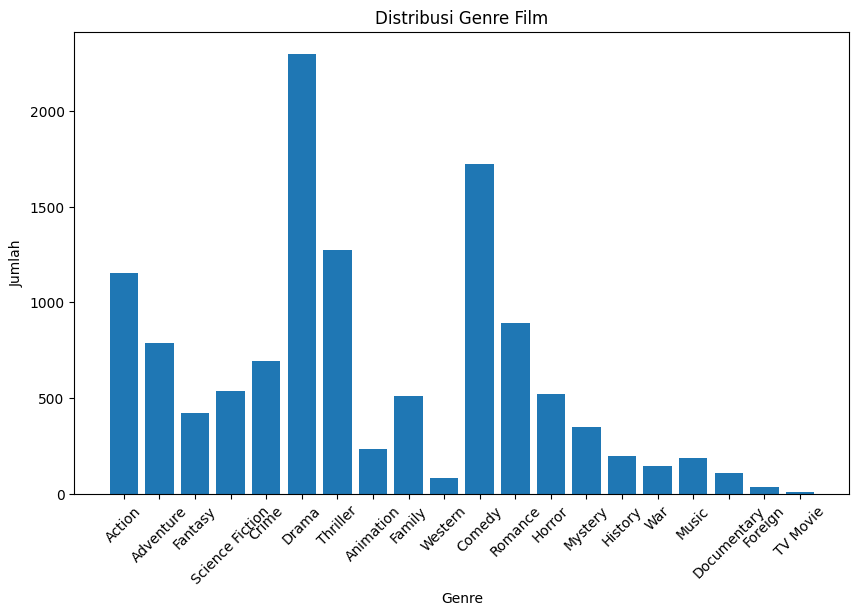

In [ ]:
# lihat distribusi genre
genre_counts = Counter()
for genres in data_gabungan['genres']:
        genre_list = ast.literal_eval(genres)
        for genre in genre_list:
            genre_counts[genre['name']] += 1


plt.figure(figsize=(10, 6))
plt.bar(genre_counts.keys(), genre_counts.values())
plt.xlabel('Genre')
plt.ylabel('Jumlah')
plt.title('Distribusi Genre Film')
plt.xticks(rotation=45)
plt.show()

In [24]:
data_gabungan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

### Handling Missing Value

Nantinya kita hanya fokus ke kolom:

    1. genres
    2. keywords
    3. overview
    4. cast
    5. crew

In [25]:
null_sebelum = data_gabungan['overview'].isna().sum()
print(f"Null values: {null_sebelum}")


Null values: 3


In [ ]:
data_gabungan['overview'] = data_gabungan['overview'].fillna('')

null_sesudah = data_gabungan['overview'].isna().sum()
print(f"Null values: {null_sesudah}")

Null values: 0


## 2. Feature Engineering

In [27]:
def nama_lengkap(text):
    try:
        data = ast.literal_eval(text)
        list_nama = [item['name'] for item in data]
        return list_nama
    except:
        return []

def top_aktor(text):
    try:
        data = ast.literal_eval(text)
        nama_aktor = [item['name'] for item in data[:3]]
        return nama_aktor
    except:
        return []

def sutradara(text):
    try:
        data = ast.literal_eval(text)
        nama_sutradara = [item['name'] for item in data if item.get('job') == 'Director']
        return nama_sutradara
    except:
        return []
    
data_gabungan['genres'] = data_gabungan['genres'].apply(nama_lengkap)
data_gabungan['keywords'] = data_gabungan['keywords'].apply(nama_lengkap)
data_gabungan['cast'] = data_gabungan['cast'].apply(top_aktor)
data_gabungan['crew'] = data_gabungan['crew'].apply(sutradara)
data_gabungan.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew
0,237000000,"[Action, Adventure, Fantasy, Science Fiction]",http://www.avatarmovie.com/,19995,"[culture clash, future, space war, space colon...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,"[Sam Worthington, Zoe Saldana, Sigourney Weaver]",[James Cameron]
1,300000000,"[Adventure, Fantasy, Action]",http://disney.go.com/disneypictures/pirates/,285,"[ocean, drug abuse, exotic island, east india ...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,"[Johnny Depp, Orlando Bloom, Keira Knightley]",[Gore Verbinski]
2,245000000,"[Action, Adventure, Crime]",http://www.sonypictures.com/movies/spectre/,206647,"[spy, based on novel, secret agent, sequel, mi...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,"[Daniel Craig, Christoph Waltz, Léa Seydoux]",[Sam Mendes]
3,250000000,"[Action, Crime, Drama, Thriller]",http://www.thedarkknightrises.com/,49026,"[dc comics, crime fighter, terrorist, secret i...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,"[Christian Bale, Michael Caine, Gary Oldman]",[Christopher Nolan]
4,260000000,"[Action, Adventure, Science Fiction]",http://movies.disney.com/john-carter,49529,"[based on novel, mars, medallion, space travel...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,"[Taylor Kitsch, Lynn Collins, Samantha Morton]",[Andrew Stanton]


In [ ]:
def cleaning_token(list_nama):
    return [nama.lower().replace(' ', '') for nama in list_nama]

data_gabungan['genres'] = data_gabungan['genres'].apply(cleaning_token)
data_gabungan['keywords'] = data_gabungan['keywords'].apply(cleaning_token)
data_gabungan['cast'] = data_gabungan['cast'].apply(cleaning_token)
data_gabungan['crew'] = data_gabungan['crew'].apply(cleaning_token)
data_gabungan['overview'] = data_gabungan['overview'].str.lower()

In [32]:
def metadata(row):
    teks_gabungan = [
        row['overview'],
        ' '.join(row['genres']),
        ' '.join(row['keywords']),
        ' '.join(row['cast']),
        ' '.join(row['crew'])
    ]
    content = ' '.join(teks_gabungan)
    return content

data_gabungan['content'] = data_gabungan.apply(metadata, axis=1)

data_gabungan['year'] = pd.to_datetime(data_gabungan['release_date']).dt.year

data_gabungan['year'] = data_gabungan['year'].fillna(0).astype(int)

df_film = pd.read_csv('tmdb_5000_movies.csv')
mapping_overview_asli = dict(zip(df_film['id'], df_film['overview']))
data_gabungan['overview'] = data_gabungan['id'].map(mapping_overview_asli)

kolom = ['id', 'title', 'year', 'overview', 'content']
data = data_gabungan[kolom]

metadata_csv = 'metadata.csv'
data.to_csv(metadata_csv, index=False)

In [33]:
metadata_df = pd.read_csv(metadata_csv)
metadata_df.head()

,id,title,year,overview,content
0,19995,Avatar,2009,"In the 22nd century, a paraplegic Marine is di...","in the 22nd century, a paraplegic marine is di..."
1,285,Pirates of the Caribbean: At World's End,2007,"Captain Barbossa, long believed to be dead, ha...","captain barbossa, long believed to be dead, ha..."
2,206647,Spectre,2015,A cryptic message from Bond’s past sends him o...,a cryptic message from bond’s past sends him o...
3,49026,The Dark Knight Rises,2012,Following the death of District Attorney Harve...,following the death of district attorney harve...
4,49529,John Carter,2012,"John Carter is a war-weary, former military ca...","john carter is a war-weary, former military ca..."


In [59]:
metadata_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       4803 non-null   int64 
 1   title    4803 non-null   object
 2   content  4803 non-null   object
dtypes: int64(1), object(2)
memory usage: 112.7+ KB


## 3. Prompt Engineering LLM

In [ ]:
KUNCI_API = " "
genai.configure(api_key=KUNCI_API)

def feature_extract(input_user):
    model = genai.GenerativeModel(
        model_name='models/gemini-flash-lite-latest',
        system_instruction=(
            "Tugas Anda adalah membaca input atau preferensi film dari pengguna "
            "(bisa dalam bahasa Indonesia maupun bahasa Inggris), lalu mengekstraknya "
            "menjadi 3 sampai 5 kata kunci (keywords) utama dalam BAHASA INGGRIS yang "
            "dipisahkan hanya dengan spasi. Jangan berikan kalimat penjelasan, pengantar, "
            "atau tanda baca lain. Contoh output: detective comedy mystery"
        )
    )
    
    respons = model.generate_content(input_user)
    keywords = respons.text.strip()
    
    return keywords

# Testing
input_indo = "Gue lagi galau, pengen nonton film petualangan luar angkasa yang sedih tapi seru"
keywords_indo = feature_extract(input_indo)

input_inggris = "I want to watch a scary horror movie about haunted house and ghosts with jumpscares"
keywords_inggris = feature_extract(input_inggris)

print(f"Input Indo: {input_indo}")
print(f"Output Keywords Indo: {keywords_indo}")
print(f"Input Inggris: {input_inggris}")
print(f"Output Keywords Inggris: {keywords_inggris}")

Input Indo: Gue lagi galau, pengen nonton film petualangan luar angkasa yang sedih tapi seru
Output Keywords Indo: space adventure emotional sci-fi
Input Inggris: I want to watch a scary horror movie about haunted house and ghosts with jumpscares
Output Keywords Inggris: horror haunted house ghosts jumpscares


## 4. TF-IDF & Cosine Silimarity

In [61]:
data_film = pd.read_csv(metadata_csv)

vectorizer = TfidfVectorizer(stop_words='english')
matriks_tfidf = vectorizer.fit_transform(data_film['content'])

def recommendation(kata_kunci, vectorizer, matriks_tfidf, df_film, top_n=5):
    key_vector = vectorizer.transform([kata_kunci])
    similarity = cosine_similarity(key_vector, matriks_tfidf).flatten()
    
    indeks_top = similarity.argsort()[-top_n:][::-1]
    
    hasil_rekomendasi = df_film.iloc[indeks_top][['title']].copy()
    hasil_rekomendasi['similarity'] = similarity[indeks_top]
    hasil_rekomendasi = hasil_rekomendasi.reset_index(drop=True)
    
    return hasil_rekomendasi

rekomendasi = recommendation(keywords_indo, vectorizer, matriks_tfidf, data_film)

print(f"Keywords: {keywords_indo}")
print()
print("Top 5 Rekomendasi Film")
print(rekomendasi.to_string(index=False))

Keywords: space adventure emotional sci-fi

Top 5 Rekomendasi Film
            title  similarity
     Galaxy Quest    0.322472
           Circle    0.208635
      Logan's Run    0.185374
A Dog's Breakfast    0.159422
           U.F.O.    0.158827


In [62]:
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

with open('tfidf_matrix.pkl', 'wb') as f:
    pickle.dump(matriks_tfidf, f)


## 5. Hyperparameter Tuning (Optuna) untuk TfidfVectorizer

### Proxy Validation

Buat dictionary berisi pasangan film uji dan sekuelnya untuk validasi sistem rekomendasi.

In [63]:
validasi_film = {
    'The Avengers': ['Avengers: Age of Ultron'],
    'The Dark Knight': ['The Dark Knight Rises'],
    'Pirates of the Caribbean: At World\'s End': ['Pirates of the Caribbean: On Stranger Tides'],
    'Iron Man': ['Iron Man 2', 'Iron Man 3'],
    'Jurassic Park': ['The Lost World: Jurassic Park', 'Jurassic Park III'],
    'The Hobbit: An Unexpected Journey': ['The Hobbit: The Desolation of Smaug'],
    'Spider-Man': ['Spider-Man 2', 'Spider-Man 3']
}

for film_asli, sekuel_list in validasi_film.items():
    print(f"- {film_asli} -> {', '.join(sekuel_list)}")

- The Avengers -> Avengers: Age of Ultron
- The Dark Knight -> The Dark Knight Rises
- Pirates of the Caribbean: At World's End -> Pirates of the Caribbean: On Stranger Tides
- Iron Man -> Iron Man 2, Iron Man 3
- Jurassic Park -> The Lost World: Jurassic Park, Jurassic Park III
- The Hobbit: An Unexpected Journey -> The Hobbit: The Desolation of Smaug
- Spider-Man -> Spider-Man 2, Spider-Man 3


### Mencari parameter TfidfVectorizer terbaik

In [ ]:
def objective(trial):
    ngram_pilihan = trial.suggest_categorical('ngram_range', [(1, 1), (1, 2)])
    max_df_nilai = trial.suggest_float('max_df', 0.7, 1.0)
    min_df_nilai = trial.suggest_int('min_df', 1, 5)
    
    tfidf = TfidfVectorizer(
        ngram_range=ngram_pilihan,
        max_df=max_df_nilai,
        min_df=min_df_nilai,
        lowercase=True,
        stop_words='english'
    )
    
    matriks_tfidf = tfidf.fit_transform(metadata['content'])
    
    similarity_matrix = cosine_similarity(matriks_tfidf)
    
    total_rr = 0.0
    jumlah_film_valid = 0
    
    for film_asli, sequels in validasi_film.items():
        cari_asli = metadata[metadata['title'].str.lower() == film_asli.lower()]
        
        if len(cari_asli) == 0:
            continue
        
        indeks_asli = cari_asli.index[0]
        
        similarity_asli = similarity_matrix[indeks_asli]
        urutan_film = similarity_asli.argsort()[::-1]
        
        posisi_seq = -1
        
        for sekuel_judul in sequels:
            cari_sekuel = metadata[metadata['title'].str.lower() == sekuel_judul.lower()]
            
            if len(cari_sekuel) == 0:
                continue
            
            indeks_sekuel = cari_sekuel.index[0]
            
            try:
                posisi_dalam_20 = list(urutan_film[:20]).index(indeks_sekuel)
                posisi_seq = posisi_dalam_20
                break
            except ValueError:
                continue
        
        if posisi_seq != -1:
            # RR = 1 / (posisi + 1), karena posisi dimulai dari 0
            rr = 1.0 / (posisi_seq + 1)
        else:
            rr = 0.0
        
        total_rr += rr
        jumlah_film_valid += 1
    
    if jumlah_film_valid > 0:
        mrr = total_rr / jumlah_film_valid
    else:
        mrr = 0.0
    
    return mrr

In [65]:
metadata = pd.read_csv('metadata.csv')

In [66]:
studi = optuna.create_study(
    direction='maximize',
    pruner=MedianPruner()
)

studi.optimize(
    objective,
    n_trials=15,
    show_progress_bar=True
)

[I 2026-05-21 12:15:48,839] A new study created in memory with name: no-name-f8b2b8a0-e21b-4474-94b1-051ff3ed03b9
  0%|          | 0/15 [00:00<?, ?it/s]c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1, 1) which is of type tuple.
  optuna_warn(message)
c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1, 2) which is of type tuple.
  optuna_warn(message)
Best trial: 0. Best value: 0.392857:   7%|▋         | 1/15 [00:00<00:09,  1.45it/s]

[I 2026-05-21 12:15:49,528] Trial 0 finished with value: 0.3928571428571429 and parameters: {'ngram_range': (1, 2), 'max_df': 0.791478665526718, 'min_df': 5}. Best is trial 0 with value: 0.3928571428571429.


Best trial: 0. Best value: 0.392857:  13%|█▎        | 2/15 [00:01<00:12,  1.04it/s]

[I 2026-05-21 12:15:50,686] Trial 1 finished with value: 0.39285714285714285 and parameters: {'ngram_range': (1, 2), 'max_df': 0.809514224806975, 'min_df': 1}. Best is trial 0 with value: 0.3928571428571429.


Best trial: 2. Best value: 0.416667:  20%|██        | 3/15 [00:02<00:10,  1.16it/s]

...

[I 2026-05-21 12:15:57,468] Trial 12 finished with value: 0.4166666666666667 and parameters: {'ngram_range': (1, 1), 'max_df': 0.878022282573493, 'min_df': 4}. Best is trial 2 with value: 0.4166666666666667.


Best trial: 2. Best value: 0.416667:  93%|█████████▎| 14/15 [00:09<00:00,  1.85it/s]

[I 2026-05-21 12:15:57,965] Trial 13 finished with value: 0.4166666666666667 and parameters: {'ngram_range': (1, 1), 'max_df': 0.9095453858631053, 'min_df': 4}. Best is trial 2 with value: 0.4166666666666667.


Best trial: 2. Best value: 0.416667: 100%|██████████| 15/15 [00:09<00:00,  1.56it/s]

[I 2026-05-21 12:15:58,465] Trial 14 finished with value: 0.4166666666666667 and parameters: {'ngram_range': (1, 1), 'max_df': 0.990867409008428, 'min_df': 4}. Best is trial 2 with value: 0.4166666666666667.


In [67]:
print(f"Mean Reciprocal Rank (MRR) Terbaik: {studi.best_value:.4f}")
print()

print("Parameter Terbaik untuk TfidfVectorizer:")
for nama_param, nilai_param in studi.best_params.items():
    print(f"- {nama_param}: {nilai_param}")

Mean Reciprocal Rank (MRR) Terbaik: 0.4167

Parameter Terbaik untuk TfidfVectorizer:
- ngram_range: (1, 2)
- max_df: 0.8158335515915235
- min_df: 4


In [68]:
best_param = {
    'ngram_range': (1, 1),
    'max_df': 0.7203209090140883,
    'min_df': 4
}

tfidf_optimal = TfidfVectorizer(
    ngram_range=best_param['ngram_range'],
    max_df=best_param['max_df'],
    min_df=best_param['min_df'],
    lowercase=True,
    stop_words='english'
)

tfidf_matrix_optimal = tfidf_optimal.fit_transform(metadata['content'])

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_optimal, f)

with open('tfidf_matrix.pkl', 'wb') as f:
    pickle.dump(tfidf_matrix_optimal, f)

## 6. Hyperparameter Tuning (Optuna) untuk CountVectorizer + K-Nearest Neighbors (KNN)

### Mencari parameter CountVectorizer dan NearestNeighbors terbaik.

In [ ]:
def objective_knn(trial):

    ngram_pilihan = trial.suggest_categorical('ngram_range', [(1, 1), (1, 2)])
    n_neighbors_nilai = trial.suggest_int('n_neighbors', 5, 20)
    
    count_vec = CountVectorizer(
        ngram_range=ngram_pilihan,
        stop_words='english',
        lowercase=True
    )
    
    matriks_count = count_vec.fit_transform(metadata['content'])
    
    model_knn = NearestNeighbors(
        n_neighbors=n_neighbors_nilai,
        metric='euclidean'
    )
    
    model_knn.fit(matriks_count)
    
    total_rr = 0.0
    jumlah_film_valid = 0
    
    for film_asli, daftar_sekuel in validasi_film.items():
        cari_asli = metadata[metadata['title'].str.lower() == film_asli.lower()]
        
        if len(cari_asli) == 0:
            continue
        
        indeks_asli = cari_asli.index[0]
        
        vektor_film_asli = matriks_count[indeks_asli]
        
        jarak, index_naighbors = model_knn.kneighbors(
            vektor_film_asli,
            n_neighbors=n_neighbors_nilai
        )
        
        index_naighbors = index_naighbors.flatten()
        
        posisi_sekuel = -1
        
        for sekuel_judul in daftar_sekuel:
            cari_sekuel = metadata[metadata['title'].str.lower() == sekuel_judul.lower()]
            
            if len(cari_sekuel) == 0:
                continue
            
            indeks_sekuel = cari_sekuel.index[0]
            
            try:
                posisi_dalam_tetangga = list(index_naighbors).index(indeks_sekuel)
                posisi_sekuel = posisi_dalam_tetangga
                break
            except ValueError:
                continue
        
        if posisi_sekuel != -1:
            # RR = 1 / (posisi + 1), karena posisi dimulai dari 0
            rr = 1.0 / (posisi_sekuel + 1)
        else:
            rr = 0.0
        
        total_rr += rr
        jumlah_film_valid += 1
    
    if jumlah_film_valid > 0:
        mrr = total_rr / jumlah_film_valid
    else:
        mrr = 0.0
    
    return mrr

In [70]:
studi_knn = optuna.create_study(direction='maximize')

studi_knn.optimize(
    objective_knn,
    n_trials=15,
    show_progress_bar=True
)

[I 2026-05-21 12:15:58,785] A new study created in memory with name: no-name-1616b6be-75f6-4567-a002-efb645a801fc
Best trial: 0. Best value: 0.0714286:   7%|▋         | 1/15 [00:00<00:03,  3.70it/s]

[I 2026-05-21 12:15:59,055] Trial 0 finished with value: 0.07142857142857142 and parameters: {'ngram_range': (1, 1), 'n_neighbors': 6}. Best is trial 0 with value: 0.07142857142857142.


Best trial: 0. Best value: 0.0714286:  13%|█▎        | 2/15 [00:01<00:08,  1.57it/s]

[I 2026-05-21 12:15:59,951] Trial 1 finished with value: 0.028571428571428574 and parameters: {'ngram_range': (1, 2), 'n_neighbors': 6}. Best is trial 0 with value: 0.07142857142857142.


Best trial: 0. Best value: 0.0714286:  20%|██        | 3/15 [00:02<00:09,  1.31it/s]

...

[I 2026-05-21 12:16:05,636] Trial 12 finished with value: 0.08095238095238096 and parameters: {'ngram_range': (1, 1), 'n_neighbors': 20}. Best is trial 10 with value: 0.08095238095238096.


Best trial: 10. Best value: 0.0809524:  93%|█████████▎| 14/15 [00:07<00:00,  2.82it/s]

[I 2026-05-21 12:16:05,923] Trial 13 finished with value: 0.08095238095238096 and parameters: {'ngram_range': (1, 1), 'n_neighbors': 20}. Best is trial 10 with value: 0.08095238095238096.


Best trial: 10. Best value: 0.0809524: 100%|██████████| 15/15 [00:07<00:00,  2.03it/s]

[I 2026-05-21 12:16:06,185] Trial 14 finished with value: 0.08035714285714286 and parameters: {'ngram_range': (1, 1), 'n_neighbors': 17}. Best is trial 10 with value: 0.08095238095238096.


In [71]:
print(f"Mean Reciprocal Rank (MRR) Terbaik: {studi_knn.best_value:.4f}")
print()

print("Parameter Terbaik untuk CountVectorizer + KNN:")
for nama_param, nilai_param in studi_knn.best_params.items():
    print(f"- {nama_param}: {nilai_param}")

Mean Reciprocal Rank (MRR) Terbaik: 0.0810

Parameter Terbaik untuk CountVectorizer + KNN:
- ngram_range: (1, 1)
- n_neighbors: 20


In [ ]:
ngram_best = studi_knn.best_params['ngram_range']
n_neighbors_best = studi_knn.best_params['n_neighbors']

count_vectorizer_best = CountVectorizer(
    ngram_range=ngram_best,
    stop_words='english',
    lowercase=True
)

matriks_count_best = count_vectorizer_best.fit_transform(metadata['content'])

knn_model_best = NearestNeighbors(
    n_neighbors=n_neighbors_best,
    metric='euclidean'
)

knn_model_best.fit(matriks_count_best)

nama_file_vectorizer = 'count_vectorizer.pkl'
with open(nama_file_vectorizer, 'wb') as file:
    pickle.dump(count_vectorizer_best, file)

nama_file_knn = 'knn_model.pkl'
with open(nama_file_knn, 'wb') as file:
    pickle.dump(knn_model_best, file)